In [1]:
%%capture
%pip -q install numpy pandas scipy matplotlib qiskit qiskit-aer qiskit-ibm-runtime pylatexenc

In [2]:
from collections import Counter
from itertools import permutations
from pathlib import Path
from typing import Any
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linear_sum_assignment
from IPython.display import display

SEED = 2026
rng = np.random.default_rng(SEED)

N_A = 4
N_B = 4
N_VARS = N_A * N_B

In [4]:
# Carga recomendada para la entrega final.
# Si existe data/dataset_real_4x4.csv, se carga automáticamente.
# Si el archivo .ipynb se abre directamente desde GitHub en Colab, pueden pegar la URL raw del CSV.

DATASET_CSV_PATH = Path("data/dataset_real_4x4.csv")
DATASET_CSV_URL = "https://raw.githubusercontent.com/RCanthony845/proyecto-programacion-cuantica/refs/heads/main/proyecto-programacion-cuantica/data/dataset_real_4x4.csv"

CARGAR_DATASET_REAL = DATASET_CSV_PATH.exists() or bool(DATASET_CSV_URL.strip())

if CARGAR_DATASET_REAL:
    if DATASET_CSV_PATH.exists():
        raw_dataset_df = pd.read_csv(DATASET_CSV_PATH)
        dataset_source = str(DATASET_CSV_PATH)
    else:
        raw_dataset_df = pd.read_csv(DATASET_CSV_URL.strip())
        dataset_source = DATASET_CSV_URL.strip()

    required_columns = {"a_id", "b_id", "score"}
    missing = required_columns - set(raw_dataset_df.columns)
    if missing:
        raise ValueError(f"El CSV debe contener las columnas {required_columns}. Faltan: {missing}")

    raw_dataset_df = raw_dataset_df.copy()
    raw_dataset_df["a_id"] = raw_dataset_df["a_id"].astype(str)
    raw_dataset_df["b_id"] = raw_dataset_df["b_id"].astype(str)
    raw_dataset_df["score"] = pd.to_numeric(raw_dataset_df["score"], errors="raise")

    if raw_dataset_df.duplicated(subset=["a_id", "b_id"]).any():
        raise ValueError("El CSV tiene pares duplicados (a_id, b_id). Debe haber exactamente un score por par.")

    a_values = list(pd.unique(raw_dataset_df["a_id"]))
    b_values = list(pd.unique(raw_dataset_df["b_id"]))

    if len(a_values) != 4 or len(b_values) != 4:
        raise ValueError("El CSV debe definir exactamente 4 valores únicos de a_id y 4 valores únicos de b_id.")

    S_loaded_df = raw_dataset_df.pivot(index="a_id", columns="b_id", values="score").loc[a_values, b_values]
    if S_loaded_df.shape != (4, 4) or S_loaded_df.isna().any().any():
        raise ValueError("El CSV debe contener exactamente un score para cada par (a_id, b_id).")

    A_df = pd.DataFrame({"id": a_values}).set_index("id")
    B_df = pd.DataFrame({"id": b_values}).set_index("id")

    if "a_nombre" in raw_dataset_df.columns:
        A_df["nombre"] = raw_dataset_df.groupby("a_id")["a_nombre"].first().loc[a_values].values
    if "b_nombre" in raw_dataset_df.columns:
        B_df["nombre"] = raw_dataset_df.groupby("b_id")["b_nombre"].first().loc[b_values].values

    S = S_loaded_df.to_numpy(dtype=float)
    S_df = pd.DataFrame(S, index=A_df.index, columns=B_df.index)
    USANDO_DATASET_MOLECULAR_DE_EJEMPLO = False
    NOMBRE_INSTANCIA = dataset_source

    print("Dataset real/semi-real cargado:", NOMBRE_INSTANCIA)
    display(A_df)
    display(B_df)
    display(S_df)
else:
    USANDO_DATASET_MOLECULAR_DE_EJEMPLO = True
    NOMBRE_INSTANCIA = "molecular_educativa_de_respaldo"
    print("No se encontró data/dataset_real_4x4.csv ni DATASET_CSV_URL. Se mantiene la instancia molecular de ejemplo.")

# Alternativa manual: si no usan CSV, pueden asignar A_df, B_df y S directamente aquí,
# siempre que documenten la fuente y la construcción de S en el README.md del repositorio.

Dataset real/semi-real cargado: https://raw.githubusercontent.com/RCanthony845/proyecto-programacion-cuantica/refs/heads/main/proyecto-programacion-cuantica/data/dataset_real_4x4.csv


""
id
insurgentes sur
anillo periferico sur
calzada tlalpan
circuito interior


""
id
carril reversible
semaforizacion inteligente
gestion dinamica
mantenimiento prioritario


id,carril reversible,semaforizacion inteligente,gestion dinamica,mantenimiento prioritario
id,,,,
insurgentes sur,0.2,0.8,0.6,0.7
anillo periferico sur,0.5,0.4,0.3,0.8
calzada tlalpan,0.6,0.8,0.6,0.8
circuito interior,0.8,0.7,0.5,0.9


In [5]:
assert len(A_df) == 4, "A_df debe tener exactamente 4 filas."
assert len(B_df) == 4, "B_df debe tener exactamente 4 filas."
assert S.shape == (4, 4), "S debe tener forma (4, 4)."
assert np.isfinite(S).all(), "S contiene valores no finitos."

print("Dataset validado: A_df, B_df y S tienen formato compatible con matching 4x4.")

Dataset validado: A_df, B_df y S tienen formato compatible con matching 4x4.


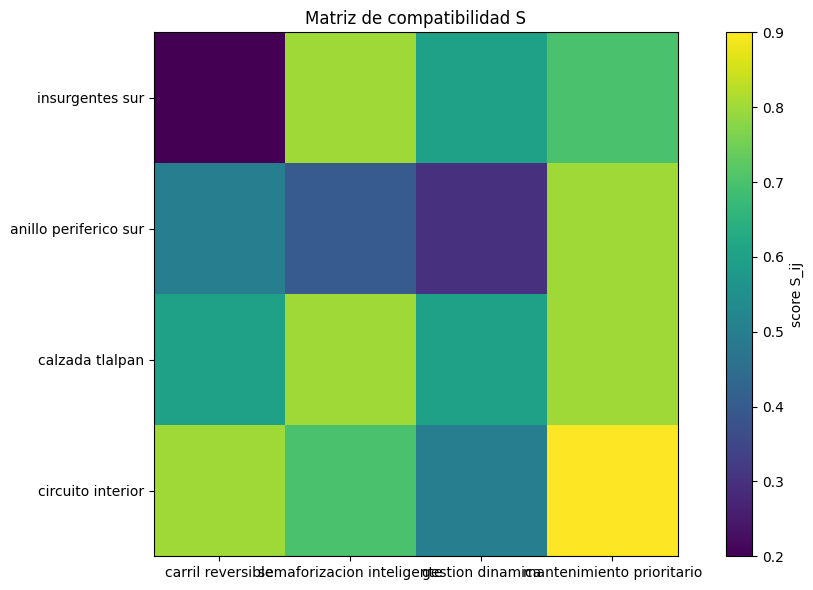

In [10]:
plt.figure(figsize=(10, 6))
plt.imshow(S)
plt.xticks(range(N_B), B_df.index)
plt.yticks(range(N_A), A_df.index)
plt.colorbar(label="score S_ij")
plt.title("Matriz de compatibilidad S")
plt.tight_layout()
plt.show()

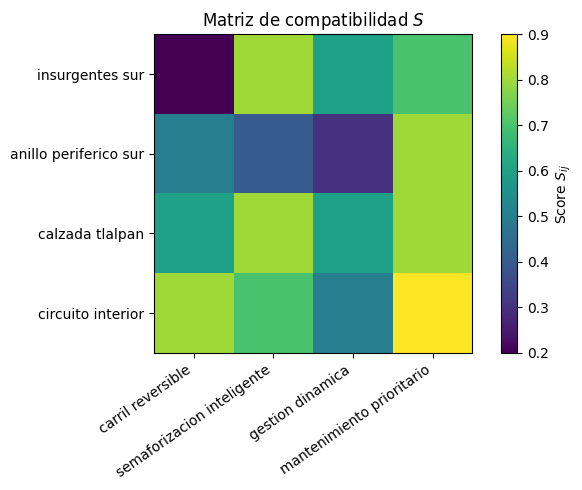

In [13]:
plt.figure(figsize=(7,5))
plt.imshow(S, cmap="viridis")
plt.xticks(
    range(N_B),
    B_df.index,
    rotation=35,
    ha="right"
)
plt.yticks(
    range(N_A),
    A_df.index
)
plt.colorbar(label="Score $S_{ij}$")
plt.title("Matriz de compatibilidad $S$")
plt.tight_layout()
plt.show()

In [14]:
def var_index(i: int, j: int, n_b: int = N_B) -> int:
    return i * n_b + j

variables = []
for i, a_id in enumerate(A_df.index):
    for j, b_id in enumerate(B_df.index):
        variables.append({
            "k": var_index(i, j),
            "variable": f"x_{a_id}_{b_id}",
            "A": a_id,
            "B": b_id,
            "score": S[i, j],
        })

variables_df = pd.DataFrame(variables).set_index("k")
display(variables_df)

,variable,A,B,score
k,,,,
0,x_insurgentes sur_carril reversible,insurgentes sur,carril reversible,0.2
1,x_insurgentes sur_semaforizacion inteligente,insurgentes sur,semaforizacion inteligente,0.8
2,x_insurgentes sur_gestion dinamica,insurgentes sur,gestion dinamica,0.6
3,x_insurgentes sur_mantenimiento prioritario,insurgentes sur,mantenimiento prioritario,0.7
4,x_anillo periferico sur_carril reversible,anillo periferico sur,carril reversible,0.5
5,x_anillo periferico sur_semaforizacion intelig...,anillo periferico sur,semaforizacion inteligente,0.4
6,x_anillo periferico sur_gestion dinamica,anillo periferico sur,gestion dinamica,0.3
7,x_anillo periferico sur_mantenimiento prioritario,anillo periferico sur,mantenimiento prioritario,0.8
8,x_calzada tlalpan_carril reversible,calzada tlalpan,carril reversible,0.6


In [15]:
def choose_penalty(score_matrix: np.ndarray) -> float:
    max_abs_score = float(np.max(np.abs(score_matrix)))
    return float(math.ceil(4.0 * max_abs_score + 1.0))

LAMBDA_A = choose_penalty(S)
LAMBDA_B = choose_penalty(S)

print("lambda_A =", LAMBDA_A)
print("lambda_B =", LAMBDA_B)

lambda_A = 5.0
lambda_B = 5.0


In [16]:
def add_exactly_one_penalty(Q: np.ndarray, group: list[int], penalty: float) -> float:
    """Agrega penalty * (sum(group) - 1)^2 al QUBO."""
    offset = float(penalty)

    for k in group:
        Q[k, k] += -penalty

    for pos, k in enumerate(group):
        for l in group[pos + 1:]:
            Q[k, l] += 2.0 * penalty

    return offset

In [17]:
def build_assignment_qubo(score_matrix: np.ndarray, lambda_a: float, lambda_b: float):
    S_local = np.asarray(score_matrix, dtype=float)
    n_a, n_b = S_local.shape
    Q = np.zeros((n_a * n_b, n_a * n_b), dtype=float)
    offset = 0.0

    for i in range(n_a):
        for j in range(n_b):
            k = var_index(i, j, n_b)
            Q[k, k] += -S_local[i, j]

    for i in range(n_a):
        group = [var_index(i, j, n_b) for j in range(n_b)]
        offset += add_exactly_one_penalty(Q, group, lambda_a)

    for j in range(n_b):
        group = [var_index(i, j, n_b) for i in range(n_a)]
        offset += add_exactly_one_penalty(Q, group, lambda_b)

    return Q, float(offset)

In [18]:
Q, qubo_offset = build_assignment_qubo(S, LAMBDA_A, LAMBDA_B)

print("Variables binarias:", N_VARS)
print("Offset QUBO:", qubo_offset)
print("Términos no nulos en Q:", int(np.count_nonzero(np.abs(Q) > 1e-12)))

Variables binarias: 16
Offset QUBO: 40.0
Términos no nulos en Q: 64


In [19]:
def qubo_terms_dataframe(Q: np.ndarray) -> pd.DataFrame:
    rows = []
    n = Q.shape[0]
    for k in range(n):
        if abs(Q[k, k]) > 1e-12:
            rows.append({"tipo": "lineal", "k": k, "l": k, "coeficiente": Q[k, k]})
        for l in range(k + 1, n):
            if abs(Q[k, l]) > 1e-12:
                rows.append({"tipo": "cuadrático", "k": k, "l": l, "coeficiente": Q[k, l]})
    return pd.DataFrame(rows)

qubo_terms_df = qubo_terms_dataframe(Q)
display(qubo_terms_df.head(20))

,tipo,k,l,coeficiente
0,lineal,0,0,-10.2
1,cuadrático,0,1,10.0
2,cuadrático,0,2,10.0
3,cuadrático,0,3,10.0
4,cuadrático,0,4,10.0
5,cuadrático,0,8,10.0
6,cuadrático,0,12,10.0
7,lineal,1,1,-10.8
8,cuadrático,1,2,10.0
9,cuadrático,1,3,10.0


In [20]:
def qubo_energy(x: np.ndarray, Q: np.ndarray, offset: float = 0.0) -> float:
    x = np.asarray(x, dtype=int)
    energy = float(offset)

    for k in range(len(x)):
        energy += Q[k, k] * x[k]

    for k in range(len(x)):
        for l in range(k + 1, len(x)):
            energy += Q[k, l] * x[k] * x[l]

    return float(energy)


def assignment_matrix(x: np.ndarray) -> np.ndarray:
    return np.asarray(x, dtype=int).reshape(N_A, N_B)

In [21]:
def is_feasible(x: np.ndarray) -> bool:
    M = assignment_matrix(x)
    return bool((M.sum(axis=1) == 1).all() and (M.sum(axis=0) == 1).all())


def assignment_score(x: np.ndarray, score_matrix: np.ndarray = S) -> float:
    return float(np.sum(assignment_matrix(x) * score_matrix))


def selected_pairs(x: np.ndarray) -> pd.DataFrame:
    M = assignment_matrix(x)
    rows = []
    for i, a_id in enumerate(A_df.index):
        for j, b_id in enumerate(B_df.index):
            if M[i, j] == 1:
                rows.append({"A": a_id, "B": b_id, "score": S[i, j]})
    return pd.DataFrame(rows)

In [22]:
def x_to_qiskit_bitstring(x: np.ndarray) -> str:
    """Convierte un vector binario x al formato de bitstring que suele reportar Qiskit."""
    x = np.asarray(x, dtype=int)
    return "".join(str(int(bit)) for bit in x[::-1])


def index_to_qiskit_bitstring(index: int, n_bits: int = N_VARS) -> str:
    """Convierte un índice de estado computacional al bitstring equivalente."""
    return format(int(index), f"0{n_bits}b")


def decode_qiskit_bitstring(bitstring: str, n_bits: int = N_VARS) -> np.ndarray:
    """Convierte un bitstring de Qiskit al vector x usado por el QUBO."""
    clean = str(bitstring).replace(" ", "").strip()
    if clean.startswith("0b"):
        clean = clean[2:]
    if len(clean) < n_bits:
        clean = clean.zfill(n_bits)
    elif len(clean) > n_bits:
        clean = clean[-n_bits:]
    return np.array([int(bit) for bit in clean[::-1]], dtype=int)


def normalizar_conteos(counts: dict | Counter | None, n_bits: int = N_VARS) -> dict[str, int] | None:
    """Normaliza conteos agregados a bitstrings de longitud fija."""
    if counts is None:
        return None

    normalized: dict[str, int] = {}
    for key, value in counts.items():
        if value is None:
            continue

        if isinstance(key, (int, np.integer)):
            bitstring = index_to_qiskit_bitstring(int(key), n_bits)
        else:
            bitstring = str(key).replace(" ", "").strip()
            if bitstring.startswith("0b"):
                bitstring = bitstring[2:]
            if len(bitstring) < n_bits:
                bitstring = bitstring.zfill(n_bits)
            elif len(bitstring) > n_bits:
                bitstring = bitstring[-n_bits:]

        normalized[bitstring] = normalized.get(bitstring, 0) + int(value)

    return normalized

In [23]:
def all_binary_vectors(n_bits: int) -> np.ndarray:
    integers = np.arange(2 ** n_bits, dtype=np.uint32)
    return ((integers[:, None] >> np.arange(n_bits)) & 1).astype(np.int8)


all_x = all_binary_vectors(N_VARS)
print("Número de configuraciones:", len(all_x))
print("Memoria de all_x en MB:", round(all_x.nbytes / 1024**2, 3))

Número de configuraciones: 65536
Memoria de all_x en MB: 1.0


In [24]:
def qubo_energy_many(X: np.ndarray, Q: np.ndarray, offset: float = 0.0) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    energies = np.full(X.shape[0], float(offset), dtype=float)

    for k in range(Q.shape[0]):
        energies += Q[k, k] * X[:, k]

    for k in range(Q.shape[0]):
        for l in range(k + 1, Q.shape[0]):
            if abs(Q[k, l]) > 1e-12:
                energies += Q[k, l] * X[:, k] * X[:, l]

    return energies


energy_by_state = qubo_energy_many(all_x, Q, qubo_offset)
best_state_index = int(np.argmin(energy_by_state))
best_x_exact = all_x[best_state_index]

In [25]:
best_energy_exact = float(energy_by_state[best_state_index])
best_score_exact = assignment_score(best_x_exact)
best_feasible_exact = is_feasible(best_x_exact)

print("Mejor energía QUBO exacta:", best_energy_exact)
print("Score de la mejor solución:", best_score_exact)
print("¿La mejor solución es factible?", best_feasible_exact)

display(pd.DataFrame(assignment_matrix(best_x_exact), index=A_df.index, columns=B_df.index))
display(selected_pairs(best_x_exact))

Mejor energía QUBO exacta: -3.0000000000000036
Score de la mejor solución: 3.0
¿La mejor solución es factible? True


id,carril reversible,semaforizacion inteligente,gestion dinamica,mantenimiento prioritario
id,,,,
insurgentes sur,0,0,1,0
anillo periferico sur,0,0,0,1
calzada tlalpan,0,1,0,0
circuito interior,1,0,0,0


,A,B,score
0,insurgentes sur,gestion dinamica,0.6
1,anillo periferico sur,mantenimiento prioritario,0.8
2,calzada tlalpan,semaforizacion inteligente,0.8
3,circuito interior,carril reversible,0.8


In [26]:
best_perm = None
best_perm_score = -np.inf

for perm in permutations(range(N_B)):
    score = sum(S[i, perm[i]] for i in range(N_A))
    if score > best_perm_score:
        best_perm_score = float(score)
        best_perm = perm

x_perm = np.zeros(N_VARS, dtype=int)
for i, j in enumerate(best_perm):
    x_perm[var_index(i, j)] = 1

print("Mejor score factible por permutaciones:", best_perm_score)
print("Energía QUBO de esa asignación:", qubo_energy(x_perm, Q, qubo_offset))
print("¿Coincide con el óptimo QUBO?", np.array_equal(x_perm, best_x_exact))

display(pd.DataFrame(assignment_matrix(x_perm), index=A_df.index, columns=B_df.index))

Mejor score factible por permutaciones: 3.0
Energía QUBO de esa asignación: -3.0000000000000018
¿Coincide con el óptimo QUBO? False


id,carril reversible,semaforizacion inteligente,gestion dinamica,mantenimiento prioritario
id,,,,
insurgentes sur,0,1,0,0
anillo periferico sur,0,0,0,1
calzada tlalpan,0,0,1,0
circuito interior,1,0,0,0


In [27]:
N_STATES = 2 ** N_VARS

energy_center = float(np.mean(energy_by_state))
energy_scale = float(np.std(energy_by_state))
if energy_scale == 0:
    energy_scale = 1.0

phase_energy = (energy_by_state - energy_center) / energy_scale

print("Estados:", N_STATES)
print("Memoria del vector de estado complejo en MB:", round((N_STATES * np.dtype(np.complex128).itemsize) / 1024**2, 3))
print("Escala usada en fases QAOA:", round(energy_scale, 4))

Estados: 65536
Memoria del vector de estado complejo en MB: 1.0
Escala usada en fases QAOA: 42.4466


In [28]:
def plus_state(n_bits: int) -> np.ndarray:
    return np.ones(2 ** n_bits, dtype=np.complex128) / math.sqrt(2 ** n_bits)


def apply_cost_phase(state: np.ndarray, gamma: float) -> np.ndarray:
    return state * np.exp(-1j * gamma * phase_energy)

In [29]:
def apply_mixer(state: np.ndarray, beta: float, n_bits: int) -> np.ndarray:
    state = state.copy()
    c = math.cos(beta)
    s = -1j * math.sin(beta)

    for k in range(n_bits):
        step = 1 << k
        block = step << 1
        view = state.reshape(-1, block)

        left = view[:, :step].copy()
        right = view[:, step:block].copy()

        view[:, :step] = c * left + s * right
        view[:, step:block] = s * left + c * right

    return state

In [30]:
QAOA_P = 1

def qaoa_state(params: np.ndarray, p: int = QAOA_P) -> np.ndarray:
    params = np.asarray(params, dtype=float)
    state = plus_state(N_VARS)

    for layer in range(p):
        gamma = params[2 * layer]
        beta = params[2 * layer + 1]
        state = apply_cost_phase(state, gamma)
        state = apply_mixer(state, beta, N_VARS)

    return state


def qaoa_expected_energy(params: np.ndarray) -> float:
    state = qaoa_state(params, QAOA_P)
    probs = np.abs(state) ** 2
    return float(np.dot(probs, energy_by_state))

In [31]:
N_RESTARTS = 10
MAXITER = 59

restart_rows = []
best_result = None

for restart in range(N_RESTARTS):
    initial = rng.uniform(low=-np.pi, high=np.pi, size=2 * QAOA_P)

    result = minimize(
        qaoa_expected_energy,
        initial,
        method="COBYLA",
        options={"maxiter": MAXITER, "rhobeg": 0.7, "disp": False},
    )

    restart_rows.append({
        "restart": restart,
        "energia_esperada": float(result.fun),
        "parametros": np.round(result.x, 4),
        "evaluaciones": result.nfev,
    })

    if best_result is None or result.fun < best_result.fun:
        best_result = result

restart_df = pd.DataFrame(restart_rows)
display(restart_df)

,restart,energia_esperada,parametros,evaluaciones
0,0,16.460005,"[-1.8464, 0.451]",59
1,1,16.568169,"[1.7816, -0.4399]",59
2,2,16.456966,"[1.8565, 2.6922]",59
3,3,16.550225,"[1.9632, -0.4408]",59
4,4,16.457325,"[1.8547, -0.4493]",59
5,5,16.660623,"[2.0123, 2.6968]",59
6,6,16.456547,"[1.8607, 2.6916]",59
7,7,16.458396,"[1.8511, 2.6928]",59
8,8,16.458192,"[1.8512, -0.4495]",59
9,9,16.461743,"[-1.8418, -2.6919]",59


In [32]:
best_params = np.asarray(best_result.x, dtype=float)
best_expected_energy = float(best_result.fun)

print("Mejores parámetros QAOA:", np.round(best_params, 6))
print("Energía esperada QAOA:", round(best_expected_energy, 6))
print("Óptimo clásico exacto:", round(best_energy_exact, 6))
print("Brecha esperada:", round(best_expected_energy - best_energy_exact, 6))

Mejores parámetros QAOA: [1.860668 2.691575]
Energía esperada QAOA: 16.456547
Óptimo clásico exacto: -3.0
Brecha esperada: 19.456547


In [34]:
qaoa_final_state = qaoa_state(best_params, QAOA_P)
qaoa_probs = np.abs(qaoa_final_state) ** 2
qaoa_probs = qaoa_probs / qaoa_probs.sum()

SHOTS_LOCAL = 5000
sampled_indices = rng.choice(N_STATES, size=SHOTS_LOCAL, replace=True, p=qaoa_probs)

# Conteos locales en formato comparable con Qiskit.
sample_counts = Counter(sampled_indices)
counts_local = Counter(index_to_qiskit_bitstring(int(idx), N_VARS) for idx in sampled_indices)

observed_indices = np.array(list(sample_counts.keys()), dtype=int)
best_observed_index = int(observed_indices[np.argmin(energy_by_state[observed_indices])])
best_x_qaoa = all_x[best_observed_index]
print("Shots locales:", SHOTS_LOCAL)
print("Bitstrings distintos observados:", len(sample_counts))
print("Mejor energía observada:", float(energy_by_state[best_observed_index]))
print("Score de la mejor muestra:", assignment_score(best_x_qaoa))
print("¿Mejor muestra factible?", is_feasible(best_x_qaoa))

display(pd.DataFrame(assignment_matrix(best_x_qaoa), index=A_df.index, columns=B_df.index))
display(selected_pairs(best_x_qaoa))

Shots locales: 5000
Bitstrings distintos observados: 2675
Mejor energía observada: -3.0000000000000036
Score de la mejor muestra: 3.0
¿Mejor muestra factible? True


id,carril reversible,semaforizacion inteligente,gestion dinamica,mantenimiento prioritario
id,,,,
insurgentes sur,0,0,1,0
anillo periferico sur,0,0,0,1
calzada tlalpan,0,1,0,0
circuito interior,1,0,0,0


,A,B,score
0,insurgentes sur,gestion dinamica,0.6
1,anillo periferico sur,mantenimiento prioritario,0.8
2,calzada tlalpan,semaforizacion inteligente,0.8
3,circuito interior,carril reversible,0.8


In [35]:
assignments_3d = all_x.reshape(N_STATES, N_A, N_B)
row_ok = (assignments_3d.sum(axis=2) == 1).all(axis=1)
col_ok = (assignments_3d.sum(axis=1) == 1).all(axis=1)
feasible_mask = row_ok & col_ok

prob_feasible = float(qaoa_probs[feasible_mask].sum())
prob_exact_optimum = float(qaoa_probs[best_state_index])

print("Probabilidad ideal de soluciones factibles:", round(prob_feasible, 6))
print("Probabilidad ideal del óptimo clásico exacto:", round(prob_exact_optimum, 6))

Probabilidad ideal de soluciones factibles: 0.026578
Probabilidad ideal del óptimo clásico exacto: 0.001129


In [36]:
top_indices = np.argsort(qaoa_probs)[::-1][:10]

top_rows = []
for rank, idx in enumerate(top_indices, start=1):
    x = all_x[idx]
    top_rows.append({
        "rank": rank,
        "probabilidad": qaoa_probs[idx],
        "energia_QUBO": energy_by_state[idx],
        "score": assignment_score(x),
        "factible": is_feasible(x),
    })

top_qaoa_df = pd.DataFrame(top_rows)
display(top_qaoa_df)

,rank,probabilidad,energia_QUBO,score,factible
0,1,0.001219,40.0,0.0,False
1,2,0.001129,-3.0,3.0,True
2,3,0.001129,-3.0,3.0,True
3,4,0.001120,-2.8,2.8,True
4,5,0.001120,-2.8,2.8,True
5,6,0.001116,-2.7,2.7,True
6,7,0.001116,-2.7,2.7,True
7,8,0.001116,-2.7,2.7,True
8,9,0.001112,-2.6,2.6,True
9,10,0.001112,-2.6,2.6,True


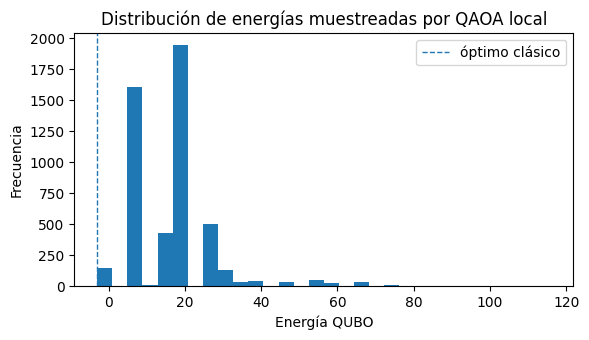

In [37]:
sampled_energies = energy_by_state[sampled_indices]

plt.figure(figsize=(6, 3.5))
plt.hist(sampled_energies, bins=30)
plt.axvline(best_energy_exact, linestyle="--", linewidth=1, label="óptimo clásico")
plt.xlabel("Energía QUBO")
plt.ylabel("Frecuencia")
plt.title("Distribución de energías muestreadas por QAOA local")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
comparison_df = pd.DataFrame([
    {
        "método": "Clásico exacto",
        "energía": best_energy_exact,
        "score": best_score_exact,
        "factible": best_feasible_exact,
        "probabilidad_factible": np.nan,
        "probabilidad_óptimo": np.nan,
    },
    {
        "método": "QAOA local: mejor muestra",
        "energía": float(energy_by_state[best_observed_index]),
        "score": assignment_score(best_x_qaoa),
        "factible": is_feasible(best_x_qaoa),
        "probabilidad_factible": prob_feasible,
        "probabilidad_óptimo": prob_exact_optimum,
    },
])

display(comparison_df)

,método,energía,score,factible,probabilidad_factible,probabilidad_óptimo
0,Clásico exacto,-3.0,3.0,True,NaN,NaN
1,QAOA local: mejor muestra,-3.0,3.0,True,0.026578,0.001129


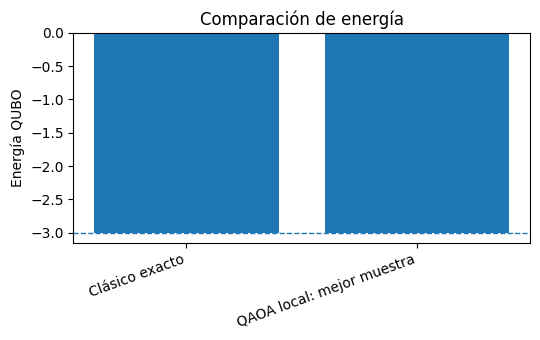

In [39]:
plt.figure(figsize=(5.5, 3.5))
plt.bar(comparison_df["método"], comparison_df["energía"])
plt.axhline(best_energy_exact, linestyle="--", linewidth=1)
plt.ylabel("Energía QUBO")
plt.title("Comparación de energía")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()